# Composition and sequence models for GCN4 speed and strength

This notebook compares a small set of regression models for predicting **speed** and **strength** from the GCN4 activation domain sequence. The requested baselines are included explicitly:

- **linear regression on amino-acid composition**
- **linear regression on one-hot encoded sequence identity**

To see whether less interpretable models help, the notebook also benchmarks a few additional regressors on the same train/test split and 5-fold cross-validation.


In [160]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from scipy.stats import pearsonr
from IPython.display import display

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNetCV, LinearRegression, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_context('talk')
sns.set_style('white')
RANDOM_STATE = 42
AMINO_ACIDS = list('ACDEFGHIKLMNPQRSTVWY')


## Load the fitted speed and strength values


In [161]:
exponential_fit = pd.read_csv('../../../output/GCN4_pipeline/speed/exponential_fit.csv', index_col=0)
exponential_fit = exponential_fit[['ADseq', 'A+C', 'k']].rename(
    columns={'A+C': 'strength', 'k': 'speed'}
)

exponential_fit.head()

,ADseq,strength,speed
0,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,1.986402,0.074620
1,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,2.129853,0.146610
2,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,1.706721,0.159460
3,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI,3.630930,0.155566
5,AAEDSSKCPSTKAGTTEPDALFNWALDVACGADPIQQWTF,3.971689,0.155898


,mean,std,min,max,n_sequences
speed,0.136850,0.048751,0.025054,0.336329,1557
strength,2.839458,1.184237,0.146219,5.855390,1557


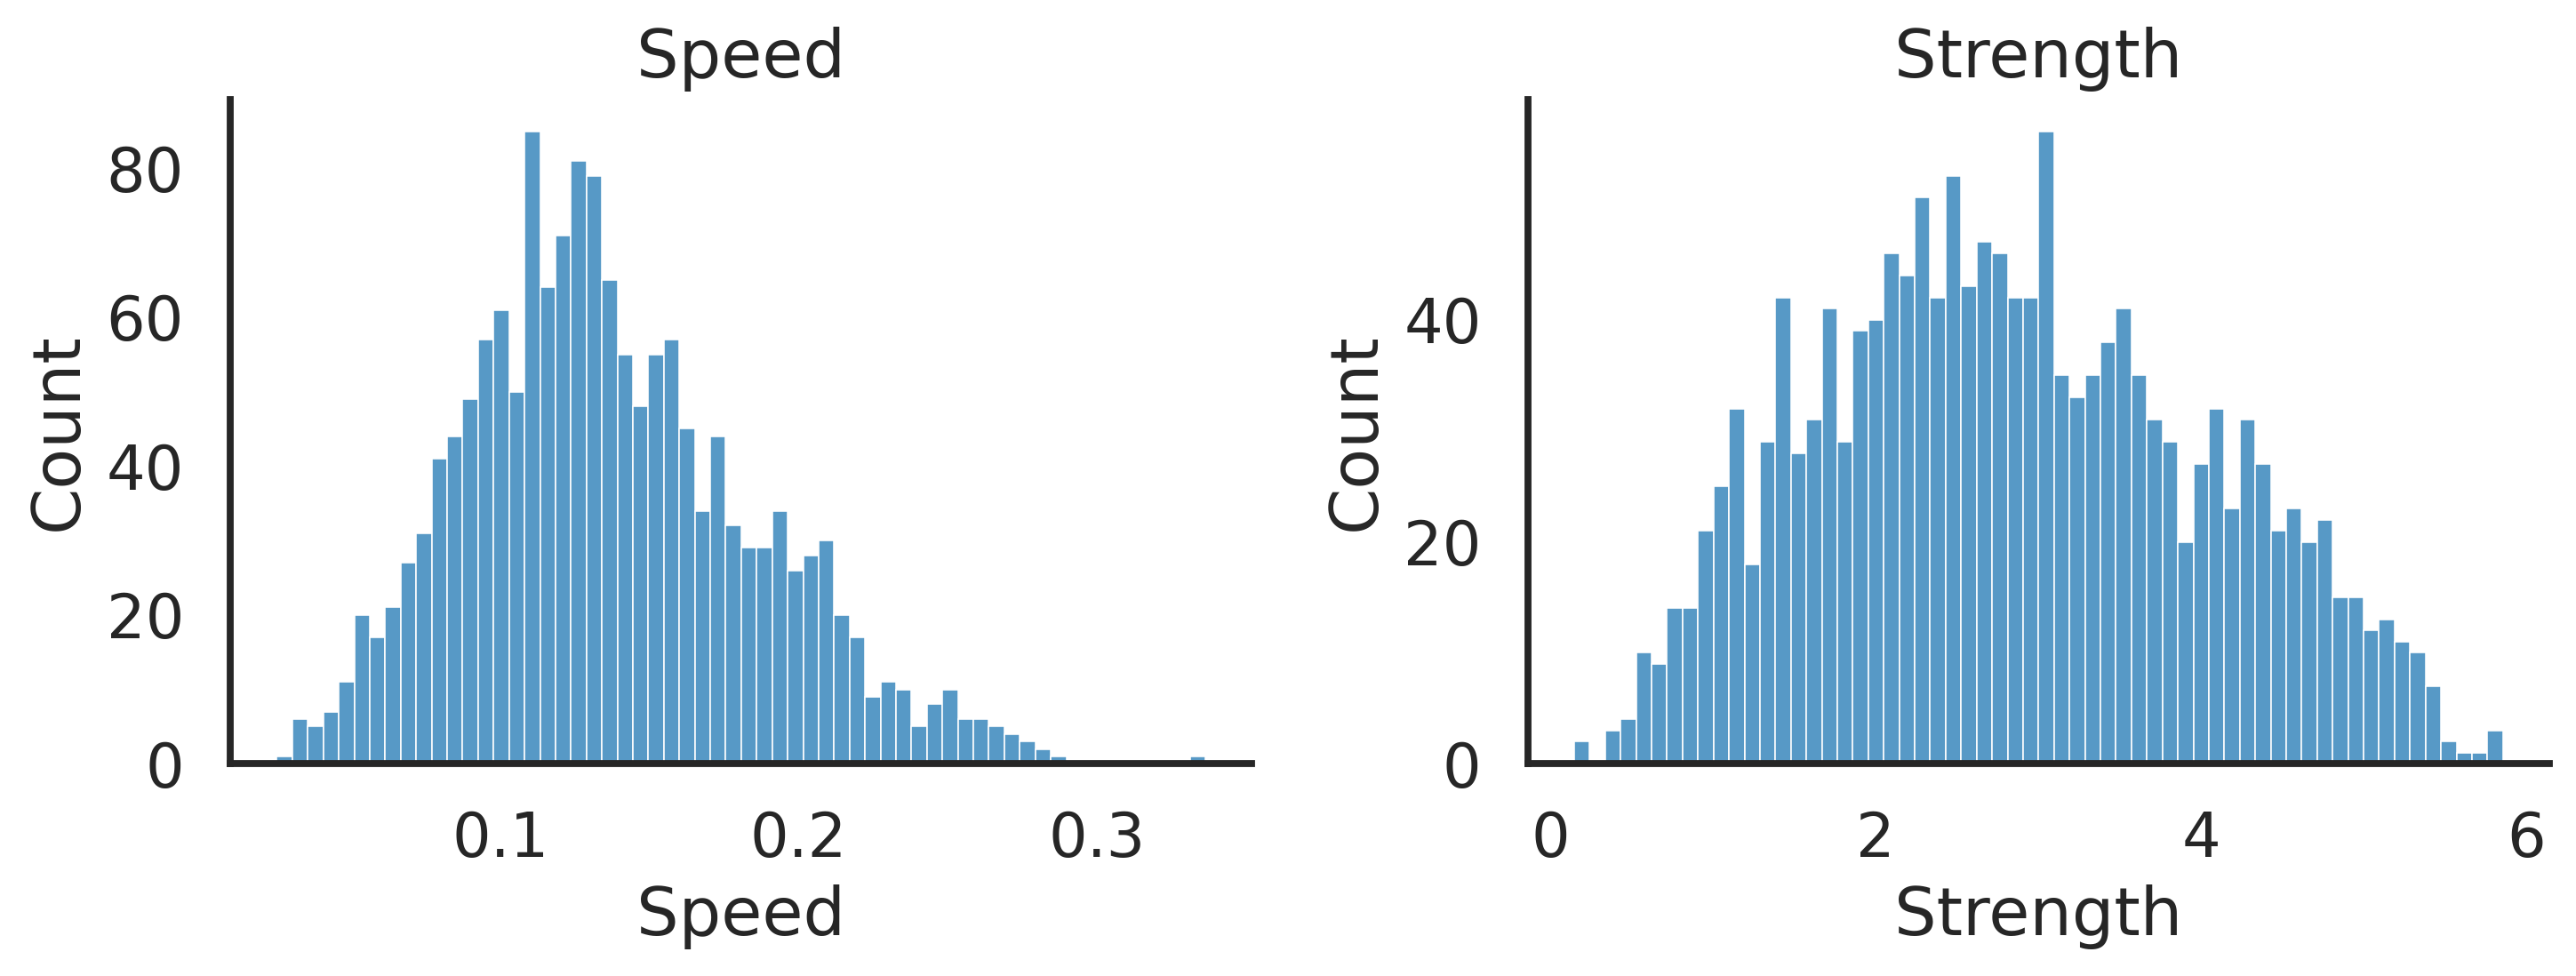

In [162]:
summary_df = exponential_fit[['speed', 'strength']].agg(['mean', 'std', 'min', 'max']).T
summary_df['n_sequences'] = len(exponential_fit)
display(summary_df)

fig, axs = plt.subplots(1, 2, figsize=(10, 4), dpi=300)
for ax, column in zip(axs, ['speed', 'strength']):
    sns.histplot(exponential_fit[column], bins=60, ax=ax)
    ax.set_title(column.capitalize())
    ax.set_xlabel(column.capitalize())
    ax.set_ylabel('Count')

sns.despine()
plt.tight_layout()

## Shared feature engineering and evaluation helpers


In [176]:
def aa_composition(seq):
    counts = Counter(seq)
    length = len(seq)
    return {aa: counts.get(aa, 0) / length for aa in AMINO_ACIDS}


def build_one_hot_features(seqs):
    seq_lengths = pd.Series(seqs).str.len()
    assert seq_lengths.nunique() == 1, 'Sequences must all have the same length'
    seq_length = int(seq_lengths.iloc[0])

    aa_to_idx = {aa: idx for idx, aa in enumerate(AMINO_ACIDS)}
    feature_names = [
        f'pos{pos + 1:02d}_{aa}'
        for pos in range(seq_length)
        for aa in AMINO_ACIDS
    ]

    encoded = np.zeros((len(seqs), seq_length * len(AMINO_ACIDS)), dtype=np.float32)
    for row_idx, seq in enumerate(seqs):
        for pos, aa in enumerate(seq):
            if aa not in aa_to_idx:
                raise ValueError(f'Unexpected amino acid {aa!r} in sequence {seq!r}')
            encoded[row_idx, pos * len(AMINO_ACIDS) + aa_to_idx[aa]] = 1.0

    return pd.DataFrame(encoded, columns=feature_names), seq_length


def safe_pearson(y_true, y_pred):
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        return np.nan
    return pearsonr(y_true, y_pred)[0]


def metric_row(y_true, y_pred, feature_set, target_name, model_name, split_name):
    return {
        'feature_set': feature_set,
        'target': target_name,
        'model': model_name,
        'split': split_name,
        'r2': r2_score(y_true, y_pred),
        'rmse': mean_squared_error(y_true, y_pred) ** 0.5,
        'pearson_r': safe_pearson(y_true, y_pred),
    }


def evaluate_model(builder, X, y, feature_set, target_name, train_idx, test_idx, cv):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y[train_idx]
    y_test = y[test_idx]

    estimator = builder()
    estimator.fit(X_train, y_train)
    y_test_pred = estimator.predict(X_test)

    cv_estimator = builder()
    y_cv_pred = cross_val_predict(cv_estimator, X, y, cv=cv)

    summary_rows = [
        metric_row(y_test, y_test_pred, feature_set, target_name, estimator.__class__.__name__, 'holdout'),
        metric_row(y, y_cv_pred, feature_set, target_name, estimator.__class__.__name__, '5-fold CV'),
    ]

    return summary_rows, {
        'estimator': estimator,
        'y_test': y_test,
        'y_test_pred': y_test_pred,
        'y_cv_pred': y_cv_pred,
    }


def benchmark_models(X, targets, model_builders, feature_set, train_idx, test_idx, cv):
    rows = []
    artifacts = {}
    for target_name, y in targets.items():
        for model_name, builder in model_builders.items():
            summary_rows, artifact = evaluate_model(
                builder, X, y, feature_set, target_name, train_idx, test_idx, cv
            )
            for row in summary_rows:
                row['model'] = model_name
            rows.extend(summary_rows)
            artifacts[(feature_set, target_name, model_name)] = artifact
    return pd.DataFrame(rows), artifacts


def coefficient_table(model, feature_names, n=12):
    coef = np.asarray(model.coef_).reshape(-1)
    coef_df = pd.DataFrame({'feature': feature_names, 'coef': coef})
    coef_df['abs_coef'] = coef_df['coef'].abs()
    return coef_df.sort_values('abs_coef', ascending=False).head(n)


def plot_prediction_grid(artifacts, feature_set, model_name, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=300, sharex=False, sharey=False)
    for ax, target_name in zip(axes, ['speed', 'strength']):
        artifact = artifacts[(feature_set, target_name, model_name)]
        y_true = artifact['y_test']
        y_pred = artifact['y_test_pred']
        lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
        ax.scatter(y_true, y_pred, alpha=0.6, edgecolors='none')
        ax.plot(lims, lims, 'r--', lw=1)
        ax.set_title(
            f"{target_name.capitalize()}\nR²={r2_score(y_true, y_pred):.2f}, r={safe_pearson(y_true, y_pred):.2f}"
        )
        ax.set_xlabel('Observed')
        ax.set_ylabel('Predicted')
    fig.suptitle(f'GCN4 {title_prefix}: {model_name}', y=0.95)
    sns.despine()
    plt.tight_layout()


## Build the composition and one-hot feature sets


In [177]:
composition_df = pd.DataFrame(exponential_fit['ADseq'].apply(aa_composition).tolist())
onehot_df, seq_length = build_one_hot_features(exponential_fit['ADseq'])

targets = {
    'speed': exponential_fit['speed'].to_numpy(),
    'strength': exponential_fit['strength'].to_numpy(),
}

train_idx, test_idx = train_test_split(
    np.arange(len(exponential_fit)), test_size=0.2, random_state=RANDOM_STATE
)
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

pd.DataFrame({
    'feature_set': ['composition', 'one_hot_sequence'],
    'n_samples': [len(composition_df), len(onehot_df)],
    'n_features': [composition_df.shape[1], onehot_df.shape[1]],
    'sequence_length': [seq_length, seq_length],
})


,feature_set,n_samples,n_features,sequence_length
0,composition,1557,20,40
1,one_hot_sequence,1557,800,40


## Requested linear-regression baselines

These are the two models you asked for directly: ordinary least-squares regression on **composition** and on **one-hot encoded sequence identity**.


In [178]:
linear_models = {'Linear regression': lambda: LinearRegression()}

composition_linear_summary, composition_linear_artifacts = benchmark_models(
    composition_df, targets, linear_models, 'composition', train_idx, test_idx, cv
)
onehot_linear_summary, onehot_linear_artifacts = benchmark_models(
    onehot_df, targets, linear_models, 'one_hot_sequence', train_idx, test_idx, cv
)

linear_summary = (
    pd.concat([composition_linear_summary, onehot_linear_summary], ignore_index=True)
      .sort_values(['split', 'target', 'r2'], ascending=[True, True, False])
      .reset_index(drop=True)
)

display(linear_summary)

,feature_set,target,model,split,r2,rmse,pearson_r
0,composition,speed,Linear regression,5-fold CV,0.307844,0.040546,0.555193
1,one_hot_sequence,speed,Linear regression,5-fold CV,-0.712286,0.063772,0.297975
2,composition,strength,Linear regression,5-fold CV,0.582526,0.764916,0.763326
3,one_hot_sequence,strength,Linear regression,5-fold CV,0.156858,1.087049,0.628041
4,composition,speed,Linear regression,holdout,0.241149,0.042315,0.502966
5,one_hot_sequence,speed,Linear regression,holdout,-0.468309,0.058860,0.345173
6,composition,strength,Linear regression,holdout,0.614481,0.750901,0.784378
7,one_hot_sequence,strength,Linear regression,holdout,0.338101,0.983911,0.712454


Top composition coefficients for speed


,feature,coef,abs_coef
18,W,0.666594,0.666594
1,C,-0.579626,0.579626
4,F,0.440198,0.440198
14,R,-0.383795,0.383795
2,D,0.283516,0.283516
10,M,0.254458,0.254458
8,K,-0.153464,0.153464
5,G,-0.102596,0.102596
17,V,-0.093819,0.093819
6,H,-0.090647,0.090647


Top composition coefficients for strength


,feature,coef,abs_coef
18,W,23.979941,23.979941
14,R,-14.715285,14.715285
4,F,14.040271,14.040271
8,K,-12.453091,12.453091
10,M,9.632442,9.632442
9,L,7.394283,7.394283
6,H,-7.245927,7.245927
13,Q,-6.629784,6.629784
5,G,-5.852772,5.852772
7,I,5.470350,5.470350


Top one-hot coefficients for speed


,feature,coef,abs_coef
221,pos12_C,-0.180791,0.180791
301,pos16_C,0.115871,0.115871
501,pos26_C,0.100021,0.100021
441,pos23_C,-0.071038,0.071038
161,pos09_C,0.065503,0.065503
1,pos01_C,0.065194,0.065194
641,pos33_C,-0.056294,0.056294
318,pos16_W,0.049774,0.049774
121,pos07_C,-0.049472,0.049472
778,pos39_W,0.049437,0.049437


Top one-hot coefficients for strength


,feature,coef,abs_coef
301,pos16_C,3.266901,3.266901
221,pos12_C,-2.103324,2.103324
441,pos23_C,-1.803116,1.803116
518,pos26_W,1.588219,1.588219
258,pos13_W,1.212702,1.212702
298,pos15_W,1.170997,1.170997
578,pos29_W,1.126487,1.126487
268,pos14_K,-1.109167,1.109167
381,pos20_C,1.054848,1.054848
658,pos33_W,1.050076,1.050076


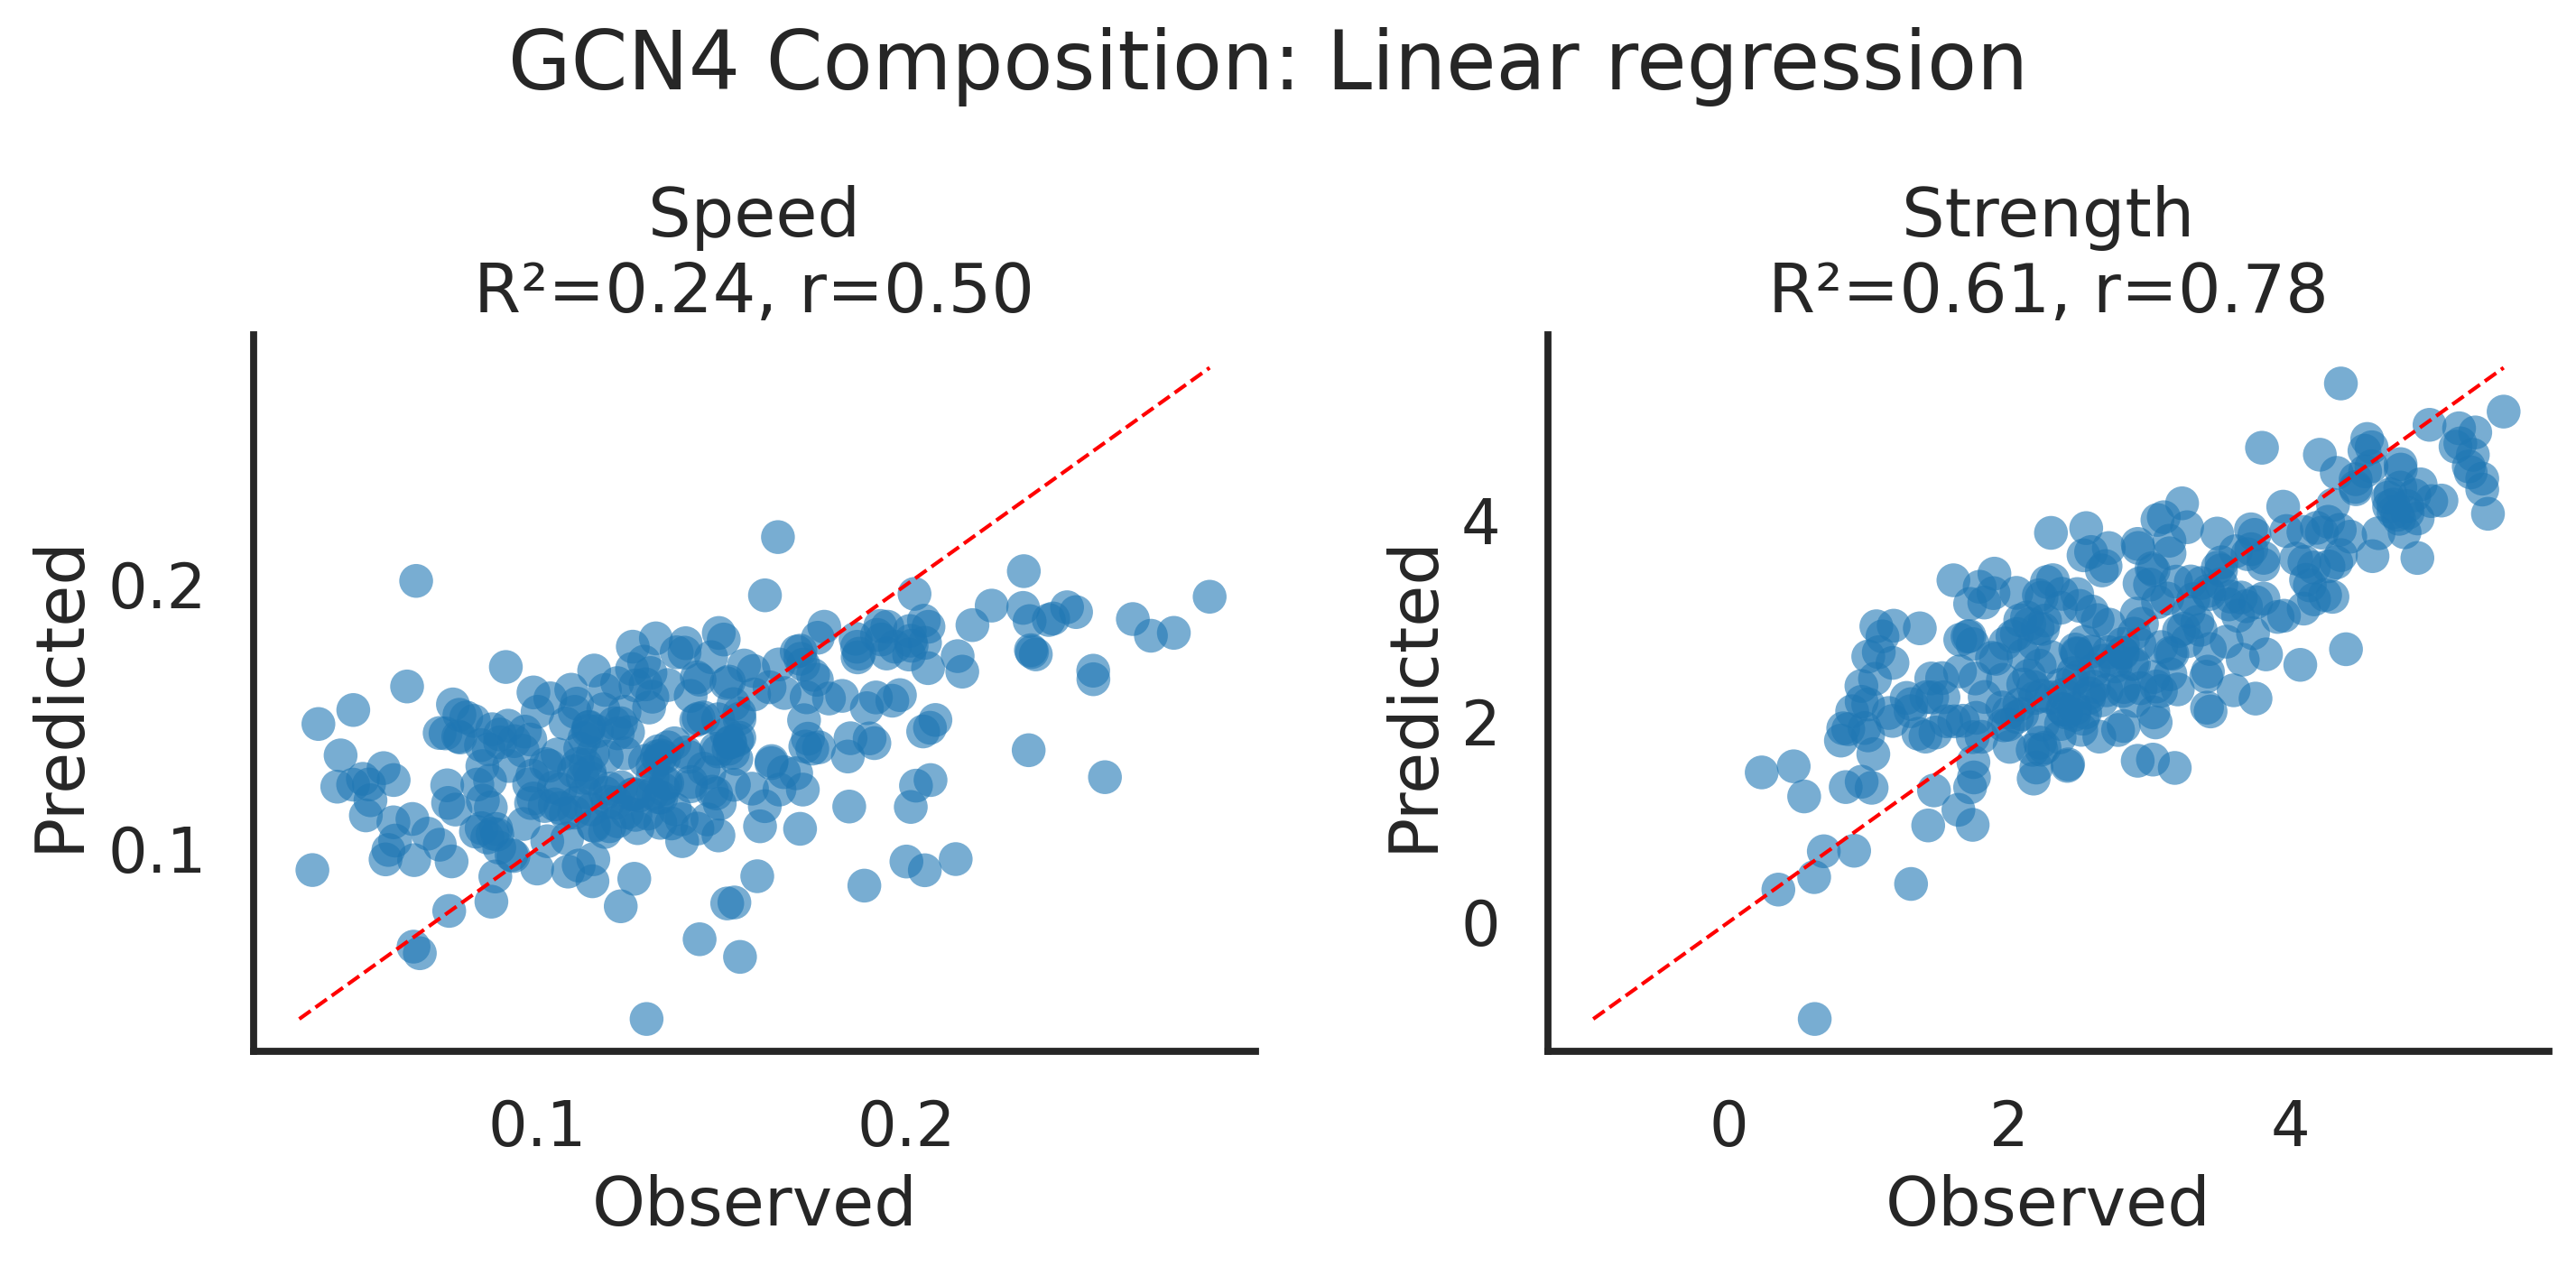

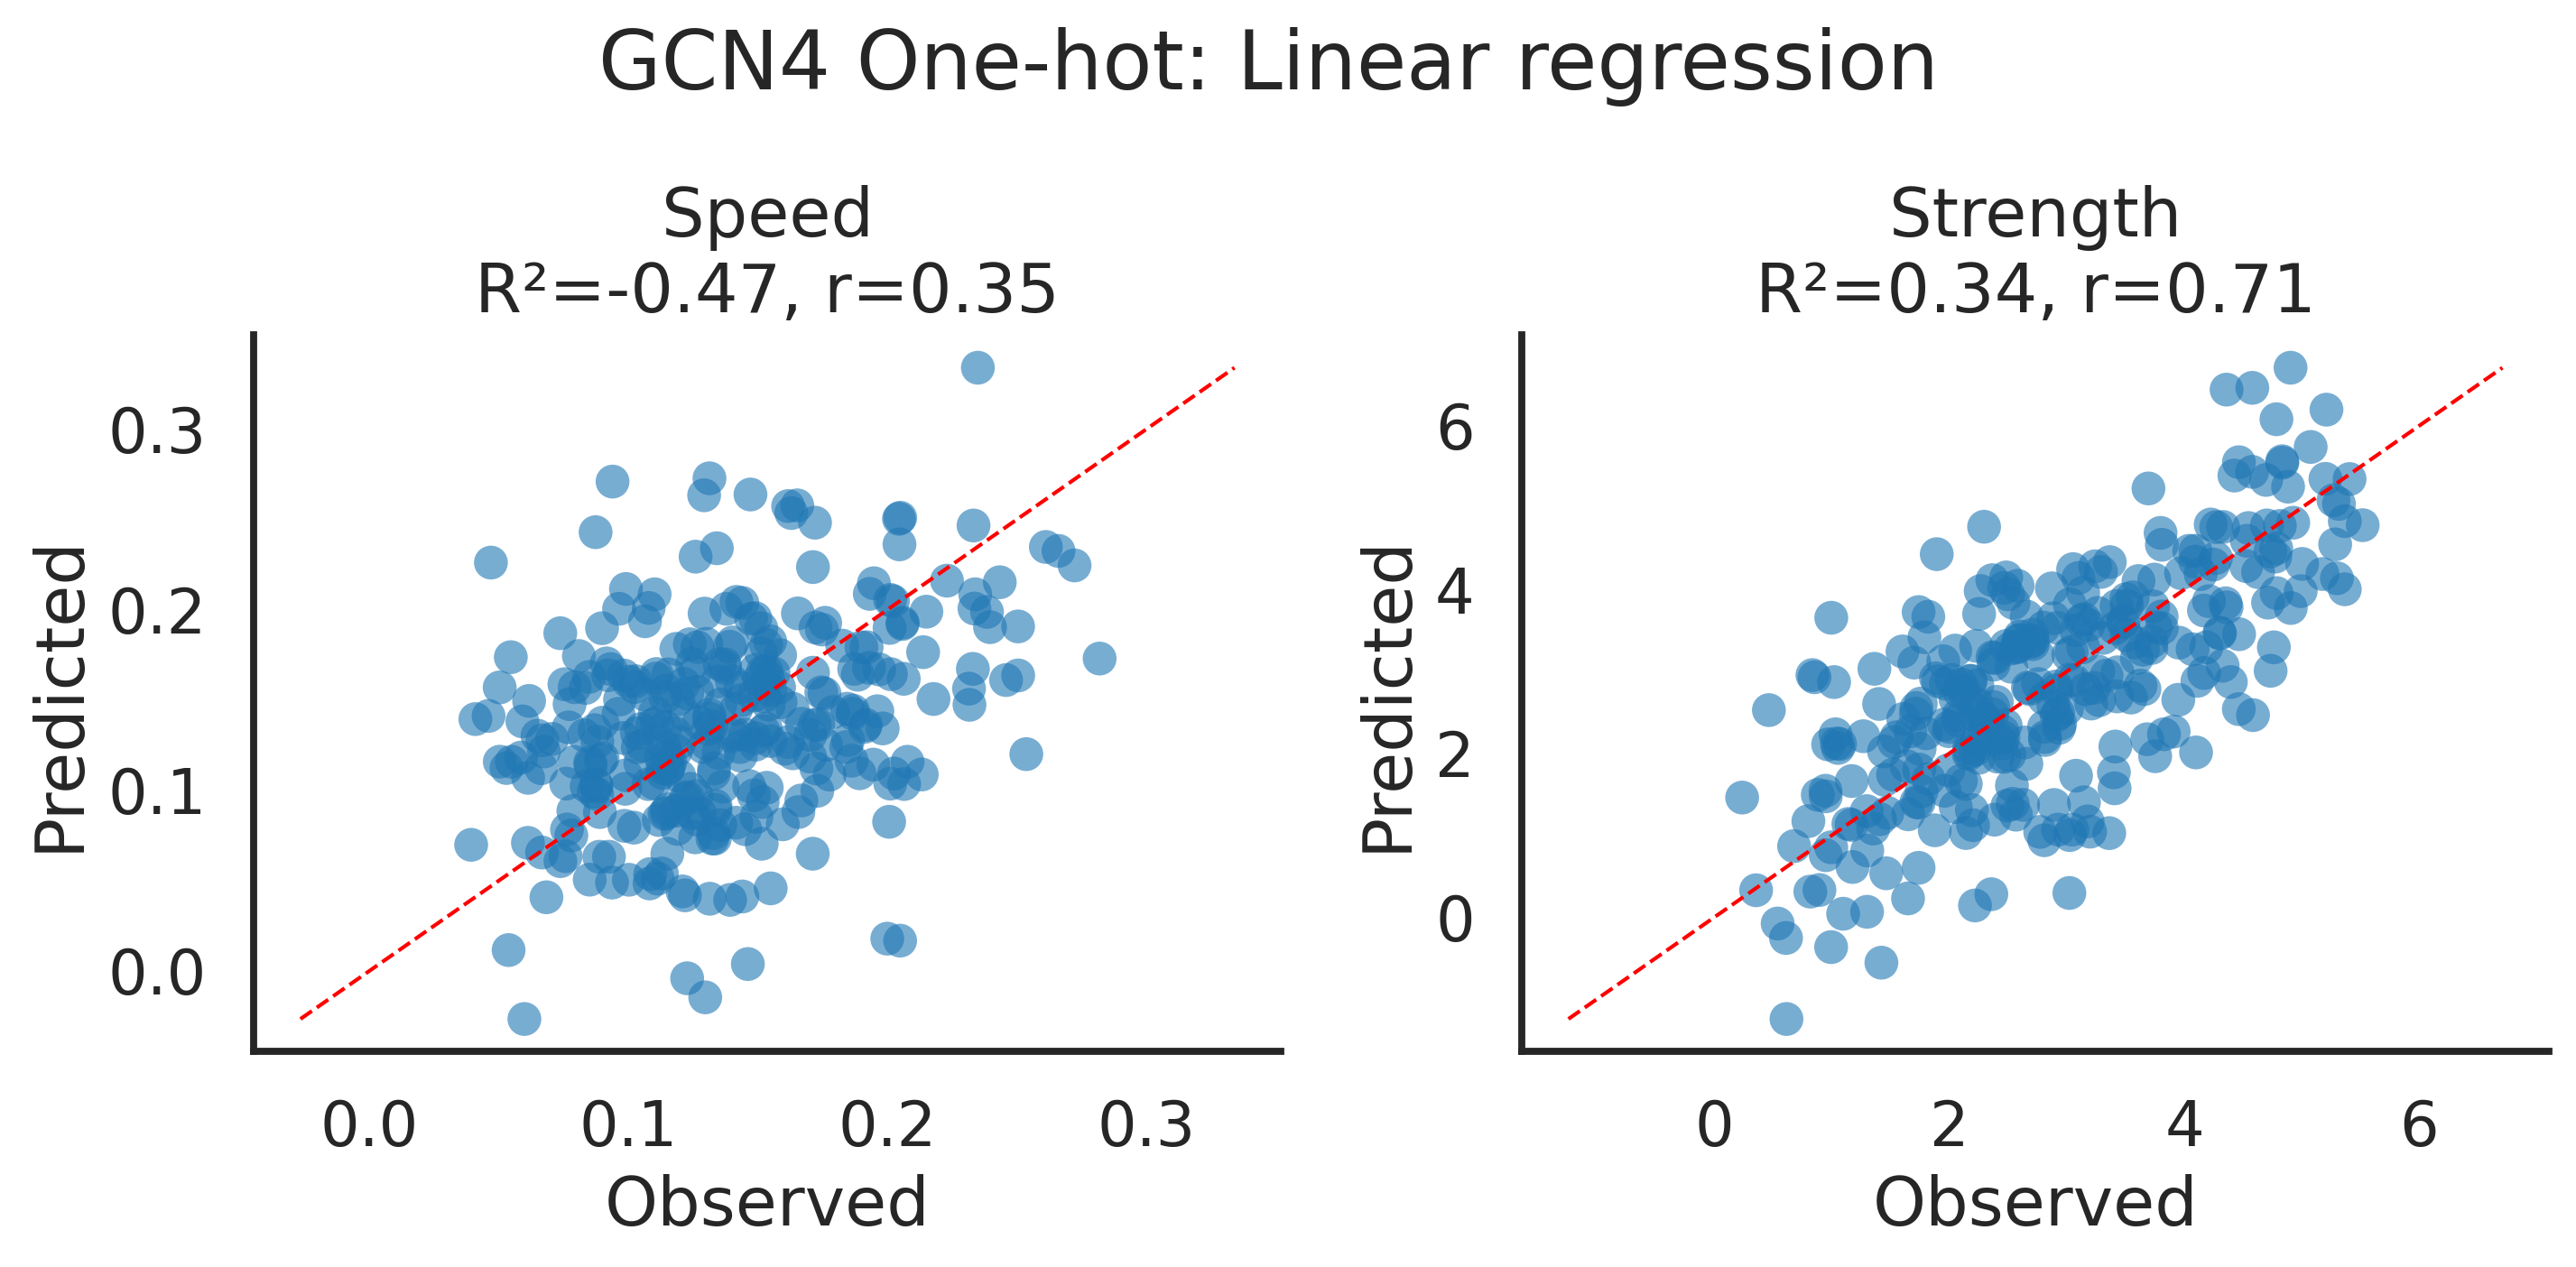

In [179]:
plot_prediction_grid(composition_linear_artifacts, 'composition', 'Linear regression', 'Composition')
plot_prediction_grid(onehot_linear_artifacts, 'one_hot_sequence', 'Linear regression', 'One-hot')

print('Top composition coefficients for speed')
display(coefficient_table(
    composition_linear_artifacts[('composition', 'speed', 'Linear regression')]['estimator'],
    composition_df.columns,
))

print('Top composition coefficients for strength')
display(coefficient_table(
    composition_linear_artifacts[('composition', 'strength', 'Linear regression')]['estimator'],
    composition_df.columns,
))

print('Top one-hot coefficients for speed')
display(coefficient_table(
    onehot_linear_artifacts[('one_hot_sequence', 'speed', 'Linear regression')]['estimator'],
    onehot_df.columns,
    n=15,
))

print('Top one-hot coefficients for strength')
display(coefficient_table(
    onehot_linear_artifacts[('one_hot_sequence', 'strength', 'Linear regression')]['estimator'],
    onehot_df.columns,
    n=15,
))